# Toy Problem: Surface Wave Inversion

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UW-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/toy_surface_wave_inversion.ipynb)

**Notebook Outline:**
- [Model parameterization (toy)](#Model-parameterization-toy)
- [Synthetic array seismograms from a dispersion curve (no PDE solve)](#Synthetic-array-seismograms-from-a-dispersion-curve-no-PDE-solve)
- [F–K spectrum + ridge picking](#F–K-spectrum-+-ridge-picking)
- [Demo: forward → synth seismograms → F–K → extracted dispersion](#Demo-forward-→-synth-seismograms-→-F–K-→-extracted-dispersion)
- [Inversion: fit c(f) with a 3-layer Vs(z)](#Inversion-fit-cf-with-a-3-layer-Vsz)
- [Discussion prompts](#Discussion-prompts)
- [Extensions](#Extensions)

---
# Toy Surface-Wave Inversion Workflow (Python-native)

```{note}


In [ ]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import brentq, least_squares
from scipy.signal import medfilt


## Model parameterization (toy)

We use a **1-D** model with **3 layers over a halfspace**, all horizontally layered.

Parameters:
- thicknesses: `h1, h2, h3` (meters)
- shear velocities: `Vs1, Vs2, Vs3, Vs4` (m/s), where `Vs4` is the halfspace
- density is fixed (toy): `rho = 2000 kg/m^3` everywhere

This is *nonlinear* because Love-wave dispersion depends on `Vs(z)` through a **transcendental dispersion relation**.


In [10]:
def love_dispersion_residual(c, omega, h, vs, rho):
    '''
    Residual of Love-wave dispersion for an N-layer stack over a halfspace.
    We enforce traction-free surface and evanescent decay in the halfspace.

    State vector: [u; tau] where u is SH displacement, tau is shear traction.
    Propagate from surface (tau=0) downward to the halfspace interface.
    In halfspace: tau = -mu * alpha * u, alpha = sqrt(k^2 - (omega/vs_half)^2).

    Returns a real residual; root ~ 0 corresponds to a mode.
    '''
    h = np.asarray(h, dtype=float)
    vs = np.asarray(vs, dtype=float)
    N = len(h)
    if np.isscalar(rho):
        rho = np.full(N+1, float(rho))
    else:
        rho = np.asarray(rho, dtype=float)

    k = omega / c  # rad/m

    # Surface BC: traction-free
    u = 1.0 + 0.0j
    tau = 0.0 + 0.0j

    # Propagate layers (top -> bottom)
    for i in range(N):
        beta = vs[i]
        mu = rho[i] * beta**2

        q = np.sqrt((omega / beta)**2 - k**2 + 0j)  # complex-safe
        if abs(q) < 1e-12:
            q = q + 1e-12j

        ch = np.cos(q * h[i])
        sh = np.sin(q * h[i])

        u_new = u * ch + (tau / (mu * q)) * sh
        tau_new = -mu * q * u * sh + tau * ch

        u, tau = u_new, tau_new

    # Halfspace decay condition
    beta_h = vs[-1]
    mu_h = rho[-1] * beta_h**2
    alpha = np.sqrt(k**2 - (omega / beta_h)**2 + 0j)
    if np.real(alpha) < 0:
        alpha = -alpha

    F = tau + mu_h * alpha * u
    return float(np.real(F))


def love_phase_velocity_fundamental(freqs, h, vs, rho=2000.0, ngrid=600):
    '''
    Compute the *fundamental* Love-wave phase velocity curve c(f)
    by bracketing and root finding at each frequency.
    '''
    freqs = np.asarray(freqs, dtype=float)
    h = np.asarray(h, dtype=float)
    vs = np.asarray(vs, dtype=float)

    c_out = np.full_like(freqs, np.nan, dtype=float)

    cmin = 0.95 * np.min(vs[:-1])   # slightly below slowest layer Vs
    cmax = 0.999 * vs[-1]           # slightly below halfspace Vs (guided)

    for j, f in enumerate(freqs):
        omega = 2*np.pi*f

        cgrid = np.linspace(cmin, cmax, ngrid)
        D = np.array([love_dispersion_residual(c, omega, h, vs, rho) for c in cgrid])

        s = np.sign(D)
        idx = np.where(s[:-1]*s[1:] < 0)[0]

        if len(idx) == 0:
            c_out[j] = cgrid[np.argmin(np.abs(D))]
            continue

        roots = []
        for i0 in idx:
            a, b = cgrid[i0], cgrid[i0+1]
            try:
                r = brentq(lambda c: love_dispersion_residual(c, omega, h, vs, rho), a, b, maxiter=200)
                roots.append(r)
            except ValueError:
                pass

        c_out[j] = np.min(roots) if roots else cgrid[np.argmin(np.abs(D))]

    return c_out


## Synthetic array seismograms from a dispersion curve (no PDE solve)

We synthesize a dispersive wave packet with the target phase velocity curve `c(f)` by building
a complex spectrum at each receiver:

$$
U_x(f) = A(f)\,e^{-i 2\pi f t_0}\,e^{-i k(f) x},\qquad k(f)=\frac{2\pi f}{c(f)}
$$

Then `irfft` gives `u(x,t)`. This is intentionally "physics-lite" but perfect for showing what an F–K plot does.


In [11]:
def synth_array_from_dispersion(x, dt, nt, f_model, c_model, f0=3.0, bw=1.0, t0=5.0, noise_std=0.02):
    '''
    Build dispersive array seismograms u(x,t) by frequency-domain synthesis.

    x: receiver positions (m)
    dt, nt: time sampling
    f_model, c_model: dispersion curve for interpolation
    '''
    x = np.asarray(x, dtype=float)
    nx = len(x)
    t = np.arange(nt)*dt

    f_fft = np.fft.rfftfreq(nt, dt)
    c_fft = np.interp(f_fft, f_model, c_model, left=np.nan, right=np.nan)

    A = np.exp(-0.5*((f_fft - f0)/bw)**2)
    A[np.isnan(c_fft)] = 0.0

    k = 2*np.pi*f_fft / np.where(c_fft>0, c_fft, np.nan)
    k[np.isnan(k)] = 0.0

    S = A * np.exp(-1j*2*np.pi*f_fft*t0)

    u = np.zeros((nx, nt), dtype=float)
    for i, xi in enumerate(x):
        spec = S * np.exp(-1j*k*xi)
        u[i, :] = np.fft.irfft(spec, n=nt)

    u = u + noise_std*np.std(u)*np.random.randn(*u.shape)
    return u, t


In [12]:
def compute_group_velocity(f, c):
    '''
    Compute group velocity U = dω/dk from phase velocity c(f).
    
    U(f) = c(f) / (1 - (f/c) * dc/df)
    '''
    f = np.asarray(f)
    c = np.asarray(c)
    dcdf = np.gradient(c, f)
    denom = 1.0 - (f / c) * dcdf
    U = c / denom
    U = np.clip(U, 0.5*np.min(c), 2.0*np.max(c))
    return U


def plot_record_section(u, x, t, title="Record Section", tmin=None, tmax=None, 
                       clip=3.0, show_wiggle=True, group_vel_overlay=None):
    '''
    Plot array seismograms u(x,t) as record section.
    '''
    u = np.asarray(u)
    x = np.asarray(x)
    t = np.asarray(t)
    
    if tmin is None:
        tmin = t[0]
    if tmax is None:
        tmax = t[-1]
    
    tmask = (t >= tmin) & (t <= tmax)
    t_plot = t[tmask]
    u_plot = u[:, tmask]
    
    std = np.std(u_plot)
    u_norm = u_plot / (clip * std)
    u_norm = np.clip(u_norm, -1, 1)
    
    fig, ax = plt.subplots(figsize=(11, 6))
    
    extent = [t_plot[0], t_plot[-1], x[0]/1000, x[-1]/1000]
    im = ax.imshow(u_norm, aspect='auto', extent=extent, cmap='seismic', 
                   vmin=-1, vmax=1, origin='lower', interpolation='bilinear')
    
    if show_wiggle:
        scale = 0.8 * (x[1] - x[0]) / 1000.0 / clip
        for i in range(0, len(x), max(1, len(x)//20)):
            trace = u_plot[i, :] / std
            offset = x[i] / 1000.0
            ax.plot(t_plot, offset + scale * trace, 'k-', lw=0.5, alpha=0.6)
    
    if group_vel_overlay is not None:
        f_band = group_vel_overlay['f']
        U_band = group_vel_overlay['U']
        t_start = group_vel_overlay.get('t_start', 0.0)
        colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(f_band)))
        for i, (f, U) in enumerate(zip(f_band, U_band)):
            t_arrival = t_start + x / U
            ax.plot(t_arrival, x/1000, '--', color=colors[i], lw=2, alpha=0.8,
                    label=f'{f:.1f} Hz: U={U:.0f} m/s')
        ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Distance (km)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3, ls=':')
    
    cbar = plt.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label('Normalized amplitude', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## F–K spectrum + ridge picking

We compute a 2-D FFT across space and time. With the sign convention \(u(x,t)\sim \cos(\omega t - kx)\),
energy concentrates along a ridge \(k(\omega)\). Convert to phase velocity:

$$
c(\omega)=\frac{\omega}{k}=\frac{2\pi f}{k}
$$

We then **pick the ridge** by taking, at each frequency, the wavenumber \(k\) of maximum amplitude (within a k-window).


In [13]:
def fk_spectrum(u, dx, dt):
    '''
    Compute |U(k,f)| from u(x,t) using a 2D FFT.

    Returns:
      f (Hz), k (rad/m), A (|U|) with f>=0 (half-spectrum).
    '''
    u = np.asarray(u, dtype=float)
    nx, nt = u.shape

    U = np.fft.fftshift(np.fft.fft2(u), axes=(0,1))
    A = np.abs(U)

    k = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2*np.pi  # rad/m
    f = np.fft.fftshift(np.fft.fftfreq(nt, d=dt))            # Hz

    pos = f >= 0
    return f[pos], k, A[:, pos]


def pick_dispersion_ridge(f, k, A, fmin=0.5, fmax=10.0, kmin=0.0, kmax=None, smooth_kernel=9):
    '''
    Ridge pick: for each frequency, pick k at max amplitude in a k-window.
    Convert to c = 2*pi*f/k.
    '''
    f = np.asarray(f)
    k = np.asarray(k)
    A = np.asarray(A)

    if kmax is None:
        kmax = np.max(k)

    # positive k only
    kpos = k > 0
    k2 = k[kpos]
    A2 = A[kpos, :]

    fmask = (f >= fmin) & (f <= fmax)
    f2 = f[fmask]
    A3 = A2[:, fmask]

    kmask = (k2 >= kmin) & (k2 <= kmax)
    k3 = k2[kmask]
    A4 = A3[kmask, :]

    c_pick = np.full_like(f2, np.nan, dtype=float)
    for j in range(len(f2)):
        i_max = np.argmax(A4[:, j])
        k_star = k3[i_max]
        c_pick[j] = 2*np.pi*f2[j] / k_star

    if smooth_kernel is not None and smooth_kernel >= 3 and smooth_kernel % 2 == 1:
        c_pick = medfilt(c_pick, kernel_size=smooth_kernel)

    return f2, c_pick


## Demo: forward → synth seismograms → F–K → extracted dispersion


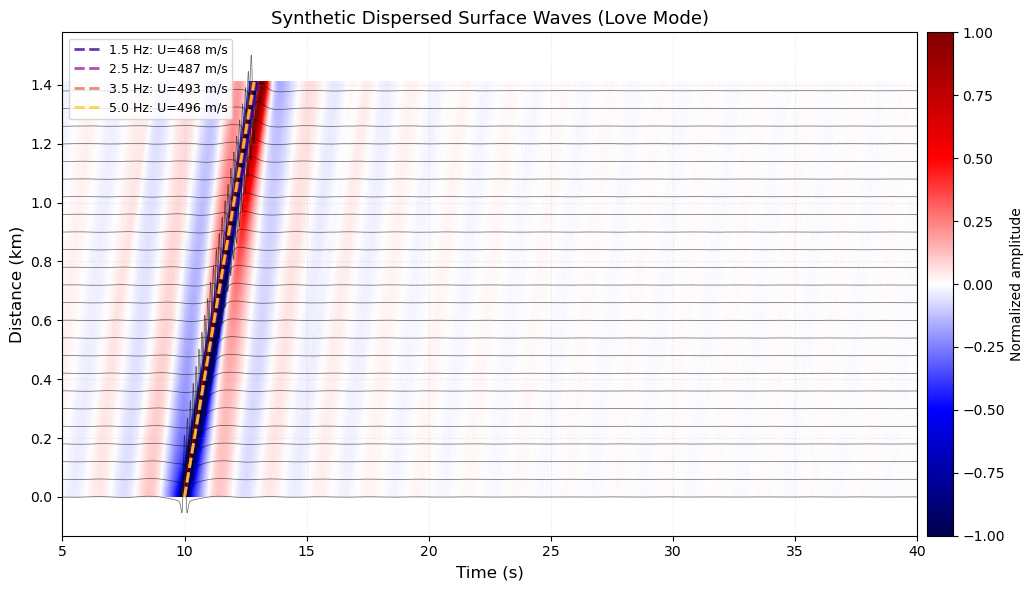

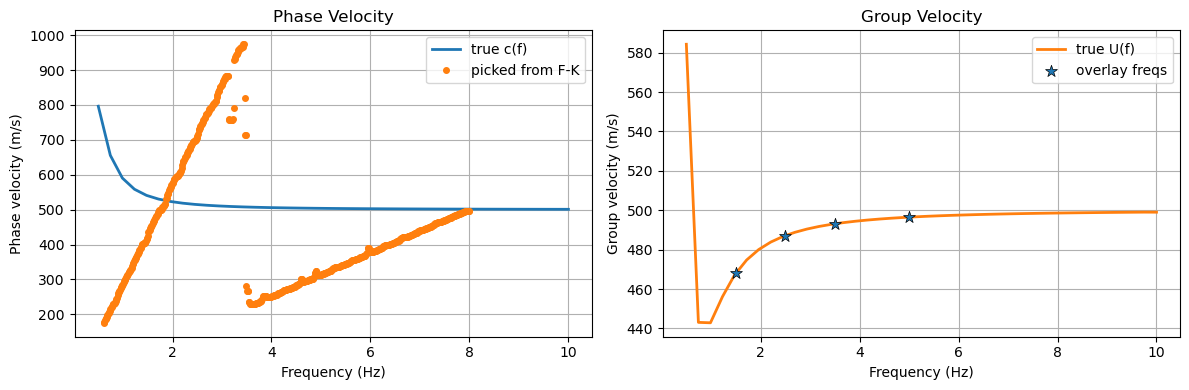

In [14]:
# --- True model (3 layers + halfspace) ---
h_true  = np.array([200.0, 500.0, 1000.0])           # m
vs_true = np.array([500.0, 900.0, 1400.0, 2500.0])   # m/s

# Frequencies for dispersion
f_model = np.linspace(0.5, 10.0, 40)
c_true  = love_phase_velocity_fundamental(f_model, h_true, vs_true, rho=2000.0)

# Compute group velocity
U_true = compute_group_velocity(f_model, c_true)

# --- Synthesize array data with improved parameters ---
nx = 48
dx = 30.0  # m
x = np.arange(nx)*dx

dt = 0.01  # s
nt = 8192  # longer time window for dispersion

u, t = synth_array_from_dispersion(x, dt, nt, f_model, c_true, 
                                   f0=3.0, bw=2.5, t0=10.0, noise_std=0.02)

# --- Plot record section with group velocity overlay ---
f_overlay = np.array([1.5, 2.5, 3.5, 5.0])
U_overlay = np.interp(f_overlay, f_model, U_true)

plot_record_section(u, x, t, 
                   title="Synthetic Dispersed Surface Waves (Love Mode)",
                   tmin=5, tmax=40, clip=2.5, show_wiggle=True,
                   group_vel_overlay={'f': f_overlay, 'U': U_overlay, 't_start': 10.0})

# --- F-K spectrum ---
f_fk, k_fk, A_fk = fk_spectrum(u, dx=dx, dt=dt)

# --- Pick ridge ---
f_obs, c_obs = pick_dispersion_ridge(f_fk, k_fk, A_fk, fmin=0.6, fmax=8.0, kmin=0.02, smooth_kernel=11)

# Plot both phase and group velocities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(f_model, c_true, label="true c(f)", lw=2)
ax1.plot(f_obs, c_obs, "o", ms=4, label="picked from F-K")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (m/s)")
ax1.set_title("Phase Velocity")
ax1.legend()
ax1.grid(True)

ax2.plot(f_model, U_true, label="true U(f)", lw=2, color='C1')
ax2.scatter(f_overlay, U_overlay, s=80, marker='*', zorder=10, 
           label="overlay freqs", edgecolor='k', linewidth=0.5)
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Group velocity (m/s)")
ax2.set_title("Group Velocity")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

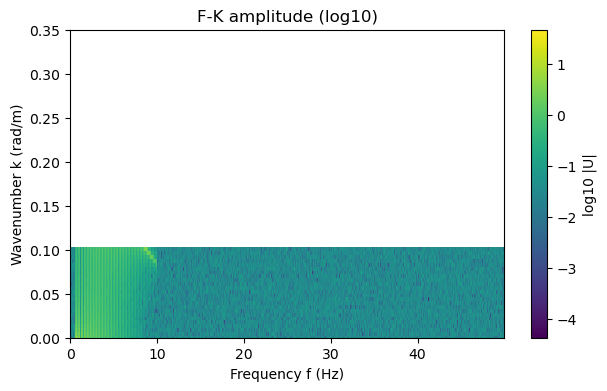

In [15]:
# Visualize the F-K amplitude (log scale)
plt.figure(figsize=(7,4))
plt.pcolormesh(f_fk, k_fk, np.log10(A_fk + 1e-12), shading="auto")
plt.xlabel("Frequency f (Hz)")
plt.ylabel("Wavenumber k (rad/m)")
plt.ylim(0, 0.35)
plt.title("F-K amplitude (log10)")
plt.colorbar(label="log10 |U|")
plt.show()


## Inversion: fit c(f) with a 3-layer Vs(z)

We define the model vector:

$$
m = [h_1,h_2,h_3, V_{S1},V_{S2},V_{S3},V_{S4}]
$$

Forward operator: \(g(m) = c_{\text{pred}}(f)\)  

Data vector: \(d = c_{\text{obs}}(f)\)

Least-squares objective (with optional smoothness regularization):

$$
\phi(m)=\left\|\frac{g(m)-d}{\sigma}\right\|_2^2 + \lambda^2\left\|\Delta V_S\right\|_2^2
$$

We solve with `scipy.optimize.least_squares` using bounds to keep parameters physical.


In [16]:
def pack_params(h, vs):
    return np.hstack([h, vs])

def unpack_params(p):
    h = p[:3]
    vs = p[3:]
    return h, vs

sigma = 30.0  # m/s (toy constant uncertainty)

def residuals(p, freqs, c_obs, lam=0.0):
    h, vs = unpack_params(p)
    c_pred = love_phase_velocity_fundamental(freqs, h, vs, rho=2000.0, ngrid=500)
    r_data = (c_pred - c_obs) / sigma

    if lam > 0:
        dv = np.diff(vs)
        r_reg = lam * dv / 500.0  # scaling for conditioning (toy)
        return np.hstack([r_data, r_reg])
    return r_data

# Initial guess
h0  = np.array([300.0, 400.0, 800.0])
vs0 = np.array([600.0, 1000.0, 1600.0, 2300.0])
p0 = pack_params(h0, vs0)

lb = pack_params([50.0, 50.0, 50.0], [200.0, 200.0, 200.0, 500.0])
ub = pack_params([2000.0, 2000.0, 3000.0], [2000.0, 3000.0, 4000.0, 5000.0])

lam = 0.8
res = least_squares(residuals, p0, bounds=(lb, ub), args=(f_obs, c_obs, lam), verbose=1, max_nfev=40)

h_est, vs_est = unpack_params(res.x)
c_est = love_phase_velocity_fundamental(f_obs, h_est, vs_est, rho=2000.0)

print("Estimated thicknesses (m):", np.round(h_est, 1))
print("Estimated Vs (m/s):", np.round(vs_est, 1))

plt.figure()
plt.plot(f_obs, c_obs, ".", label="picked data")
plt.plot(f_model, c_true, label="true")
plt.plot(f_obs, c_est, "--", label="fit")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()


/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_74403/2599251142.py:50: RuntimeWarning: overflow encountered in scalar multiply
  F = tau + mu_h * alpha * u
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_74403/2599251142.py:39: RuntimeWarning: overflow encountered in scalar multiply
  tau_new = -mu * q * u * sh + tau * ch
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_74403/2599251142.py:50: RuntimeWarning: overflow encountered in scalar add
  F = tau + mu_h * alpha * u
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_74403/2599251142.py:39: RuntimeWarning: overflow encountered in scalar add
  tau_new = -mu * q * u * sh + tau * ch
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_74403/2599251142.py:38: RuntimeWarning: overflow encountered in scalar multiply
  u_new = u * ch + (tau / (mu * q)) * sh
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_74403/2599251142.py:50: RuntimeWarning: invalid value encountered in scalar m

KeyboardInterrupt: 

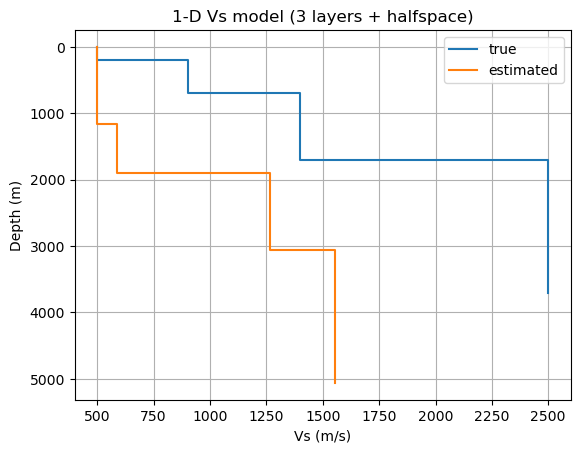

In [ ]:
def plot_vs_profile(h, vs, label=None):
    h = np.asarray(h)
    vs = np.asarray(vs)
    z_edges = np.concatenate([[0], np.cumsum(h)])
    z_max = z_edges[-1] + 2000

    z = [0.0]
    v = [vs[0]]
    z0 = 0.0
    for i, hi in enumerate(h):
        z1 = z0 + hi
        z += [z1, z1]
        v += [vs[i], vs[i+1]]
        z0 = z1
    z += [z_max]
    v += [vs[-1]]
    plt.plot(v, z, label=label)

plt.figure()
plot_vs_profile(h_true, vs_true, label="true")
plot_vs_profile(h_est, vs_est, label="estimated")
plt.gca().invert_yaxis()
plt.xlabel("Vs (m/s)")
plt.ylabel("Depth (m)")
plt.legend()
plt.grid(True)
plt.title("1-D Vs model (3 layers + halfspace)")
plt.show()


## Discussion prompts

- Which frequencies constrain the shallowest layer most strongly? Why?
- Increase **dx**: when do you see spatial aliasing in F–K? How does it corrupt picked c(f)?
- Hold `h` fixed and invert only `Vs`: does the fit improve or worsen? What does that say about trade-offs?
- Increase regularization `lam`: what changes in Vs(z) and in the misfit?

## Extensions

- Add a second mode in the synthetic wavefield (two ridges) and discuss mode mixing.
- Replace ridge-picking by a weighted centroid in k (soft picks with uncertainties).
- Compare phase-velocity inversion to group-velocity inversion (time–frequency methods).
